# Weaver eval analysis

Analysis of the offline eval harness output (`scripts/run_evals.py` -> `evals/results/<UTC>/runs.csv`).

Each hypothesis maps to columns already produced by `services/telemetry.py`. All metrics are objective: token counts, structural counts, validation booleans, and reference-based deltas vs the gold workflows in `prompts/workflows.json`. No LLM-as-judge, no Likert.

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Visual defaults tuned for a notebook with 20 fixtures and 3 runs each.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def short_name(name: str, n: int = 32) -> str:
    """Truncate fixture names so they fit on plot axes."""
    name = str(name)
    return name if len(name) <= n else name[: n - 1].rstrip() + "\u2026"


REPO_ROOT = Path.cwd().parent if Path.cwd().name in ("notebooks", "scripts") else Path.cwd()
RESULTS_ROOT = REPO_ROOT / "evals" / "results"

available = sorted([p for p in RESULTS_ROOT.iterdir() if (p / "runs.csv").exists()])
print(f"Found {len(available)} run(s) with data:")
for p in available:
    print(" -", p.name)

# Pick the most recent non-empty run by default; override below to pin a specific timestamp.
RUN_DIR = available[-1]
print("\nUsing:", RUN_DIR.name)

Found 4 run(s) with data:
 - 2026-05-21T14-56-03Z
 - 2026-05-21T15-13-23Z
 - 2026-05-23T16-33-26Z
 - 2026-05-24T12-21-37Z

Using: 2026-05-24T12-21-37Z


In [2]:
df = pd.read_csv(RUN_DIR / "runs.csv")
summary = pd.read_csv(RUN_DIR / "summary.csv")
headline = json.loads((RUN_DIR / "summary.json").read_text())

# errors and element_type_counts arrive as JSON strings; decode for analysis.
df["errors"] = df["errors"].fillna("[]").apply(json.loads)
df["element_type_counts"] = df["element_type_counts"].fillna("{}").apply(json.loads)

# Short labels for plotting.
df["fixture"] = df["process_name"].map(short_name)

print("Headline rates:", headline["rates"])
print("Total tokens:", headline["totals"]["total_tokens"], "  Wall:", headline["wall_seconds"], "s")
print("\nFixtures (n_runs each):")
print(df.groupby("process_name").size().to_string())
df.head()

Headline rates: {'parsed_ok': 0.95, 'schema_pass': 0.95, 'semantic_pass': 0.9333}
Total tokens: 394981   Wall: 3610.27 s

Fixtures (n_runs each):
process_name
Beam Automated Scribe for Community Care Worker      3
Civic AI Casework Triage                             3
Civic AI Congressional Correspondence                3
Civic AI Constituent Sentiment Analysis              3
Civic AI Social Media Drafting                       3
Claim Generative Engine Optimization for Webpages    3
CrowdAI Dented Can Identification                    3
CrowdAI Fireline Spot Fire Identification            3
Indian Railway Expenditure Agent                     3
Indian Railway Smart AI Assistant                    3
KyklosTech Guideline-Integrated Decision Engine      3
Laurettaio Video Anomaly Detector                    3
Mastercard Transaction Risk Monitoring               3
NHS Automated Medical Triage                         3
NHS Automated Scribe for Clinician                   3
NHS Blood Test L

,process_name,run_idx,parsed_ok,schema_pass,semantic_pass,errors,finish_reason,api_error,prompt_tokens,completion_tokens,total_tokens,latency_ms,num_elements,num_flows,element_type_counts,num_final_outcomes,branching_factor,max_path_length,has_cycle,element_count_delta,flow_count_delta,element_type_jaccard_multiset,gold_type_coverage,final_outcome_recall,fixture
0,Beam Automated Scribe for Community Care Worker,0,True,True,True,[],stop,NaN,3806,4462,8268,55727,21,25,"{'humanSource': 2, 'inputOutput': 5, 'ui': 4, ...",2,3.0,NaN,True,3,4,0.4444,0.8889,1.0,Beam Automated Scribe for Commu…
1,Beam Automated Scribe for Community Care Worker,1,True,True,True,[],stop,NaN,3806,4519,8325,109155,18,22,"{'humanSource': 2, 'inputOutput': 5, 'ui': 1, ...",2,3.5,NaN,True,0,1,0.5652,0.8889,1.0,Beam Automated Scribe for Commu…
2,Beam Automated Scribe for Community Care Worker,2,True,True,True,[],stop,NaN,3806,4490,8296,50380,18,22,"{'humanSource': 2, 'inputOutput': 4, 'ui': 2, ...",1,3.5,NaN,True,0,1,0.5652,0.8889,0.5,Beam Automated Scribe for Commu…
3,Civic AI Casework Triage,0,True,True,True,[],stop,NaN,3829,5508,9337,52047,21,24,"{'humanSource': 2, 'inputOutput': 5, 'fixedAIM...",3,3.0,14.0,False,6,8,0.6364,1.0000,1.0,Civic AI Casework Triage
4,Civic AI Casework Triage,1,True,True,True,[],stop,NaN,3829,4678,8507,45259,18,20,"{'inputOutput': 7, 'fixedAIModel': 3, 'humanSo...",2,3.0,NaN,True,3,4,0.7368,1.0000,1.0,Civic AI Casework Triage


## Gold reference shape

Load the gold traces from `prompts/workflows.json` so we can compare prediction sizes to ground-truth sizes per fixture.

In [3]:
gold = json.loads((REPO_ROOT / "prompts" / "workflows.json").read_text(encoding="utf-8"))
gold_df = pd.DataFrame([
    {
        "process_name": w["assistant"]["process_name"],
        "gold_elements": len(w["assistant"]["elements"]),
        "gold_flows": len(w["assistant"]["flows"]),
        "gold_types": len({e["type"] for e in w["assistant"]["elements"]}),
        "gold_final_outcomes": sum(1 for e in w["assistant"]["elements"] if e["type"] == "finalOutcome"),
    }
    for w in gold
])
df = df.merge(gold_df, on="process_name", how="left")
gold_df[gold_df["process_name"].isin(df["process_name"].unique())]

,process_name,gold_elements,gold_flows,gold_types,gold_final_outcomes
0,Beam Automated Scribe for Community Care Worker,18,21,9,2
1,Civic AI Casework Triage,15,16,7,1
2,Civic AI Congressional Correspondence,14,15,7,1
3,Civic AI Constituent Sentiment Analysis,6,5,4,1
4,Civic AI Social Media Drafting,8,8,7,1
5,Claim Generative Engine Optimization for Webpages,12,13,8,1
6,CrowdAI Dented Can Identification,12,13,8,1
7,CrowdAI Fireline Spot Fire Identification,12,13,8,1
8,Indian Railway Expenditure Agent,8,8,7,1
9,Indian Railway Smart AI Assistant,8,8,7,1


## H1 - Failures concentrate at the semantic layer

**Claim:** Pass rates follow the order parse >= schema >= semantic, with most failures at the semantic layer (orphan/dead-end nodes, multi-entry, terminal-with-outgoing).

**Why it matters:** If parse and schema are near-perfect but semantic fails, prompt edits + post-validation are the leverage point, not retraining or a different model.

,tier,pass_rate,n_fail
0,parsed_ok,0.950000,3
1,schema_pass,0.950000,3
2,semantic_pass,0.933333,4


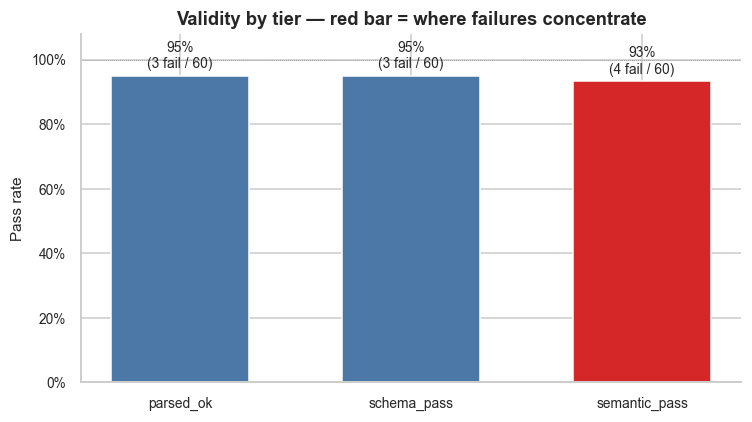

In [4]:
tiers = pd.DataFrame({
    "tier": ["parsed_ok", "schema_pass", "semantic_pass"],
    "pass_rate": [df["parsed_ok"].mean(), df["schema_pass"].mean(), df["semantic_pass"].mean()],
    "n_fail": [(~df["parsed_ok"]).sum(), (~df["schema_pass"]).sum(), (~df["semantic_pass"]).sum()],
})
display(tiers)

fig, ax = plt.subplots(figsize=(7, 4))
# Color the weakest tier red; the rest neutral grey.
weakest = tiers["pass_rate"].idxmin()
colors = ["#4c78a8" if i != weakest else "#d62728" for i in range(len(tiers))]
bars = ax.bar(tiers["tier"], tiers["pass_rate"], color=colors, edgecolor="white", width=0.6)

ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Pass rate")
ax.set_xlabel("")
ax.set_title("Validity by tier — red bar = where failures concentrate")
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle=":")

for bar, (_, r) in zip(bars, tiers.iterrows()):
    label = f"{r['pass_rate']:.0%}\n({r['n_fail']} fail / {len(df)})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

,n
family,
other,3
dead_end,1


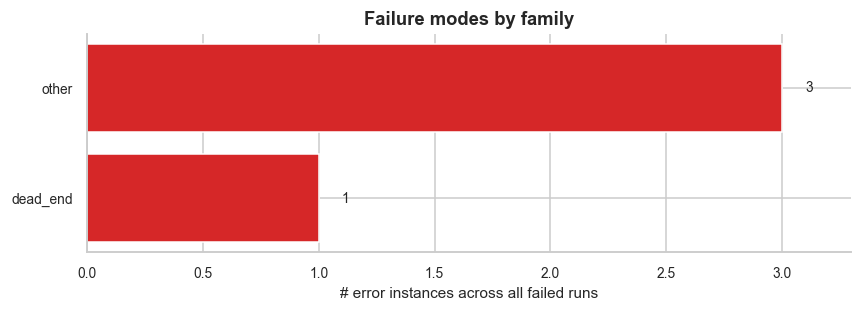

In [5]:
# Semantic error taxonomy: which error families fire most often?
def classify(msg: str) -> str:
    m = msg.lower()
    if "dead end" in m or "no outgoing flows" in m:
        return "dead_end"
    if "multiple entry" in m or "entry point" in m:
        return "multi_entry"
    if "terminal node" in m and "outgoing" in m:
        return "terminal_with_outgoing"
    if "schema error" in m or "additional properties" in m:
        return "schema"
    if "flow ref" in m or ("invalid" in m and "id" in m):
        return "bad_flow_ref"
    if "duplicate" in m:
        return "duplicate_id"
    return "other"

err_rows = []
for _, r in df[~df["semantic_pass"] | ~df["schema_pass"]].iterrows():
    for e in r["errors"]:
        err_rows.append({"process_name": r["process_name"], "family": classify(str(e)), "message": str(e)})
errs = pd.DataFrame(err_rows)

if not errs.empty:
    fam = errs.groupby("family").size().sort_values(ascending=True).rename("n")
    display(fam.sort_values(ascending=False).to_frame())

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(fam) + 1)))
    bars = ax.barh(fam.index, fam.values, color="#d62728", edgecolor="white")
    ax.set_xlabel("# error instances across all failed runs")
    ax.set_title("Failure modes by family")
    for bar, v in zip(bars, fam.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                str(int(v)), va="center", fontsize=9)
    ax.margins(x=0.1)
    plt.tight_layout()
    plt.show()
else:
    print("No failures in this run.")

## H2 - Predictions inflate vs gold (over-generation)

**Claim:** `element_count_delta = predicted - gold` is positive on average, meaning the LLM elaborates user descriptions into more nodes than the gold trace contains.

**Why it matters:** If true, the post-edit human cost is *trimming* spurious nodes, not adding missing ones. That informs the UI affordances we should prioritize.

,element_count_delta,flow_count_delta,gold_elements,gold_flows,element_ratio
process_name,,,,,
Beam Automated Scribe for Community Care Worker,1.00,2.00,18.0,21.0,1.06
Civic AI Casework Triage,4.00,5.67,15.0,16.0,1.27
Civic AI Congressional Correspondence,2.33,4.33,14.0,15.0,1.17
Civic AI Constituent Sentiment Analysis,8.00,13.00,6.0,5.0,2.33
Civic AI Social Media Drafting,5.67,7.00,8.0,8.0,1.71
Claim Generative Engine Optimization for Webpages,2.00,3.00,12.0,13.0,1.17
CrowdAI Dented Can Identification,0.67,1.33,12.0,13.0,1.06
CrowdAI Fireline Spot Fire Identification,1.00,2.00,12.0,13.0,1.08
Indian Railway Expenditure Agent,1.67,2.33,8.0,8.0,1.21



Element delta: mean=0.85, t=1.04, p=0.3035
Flow delta:    mean=2.22, t=2.21, p=0.0308


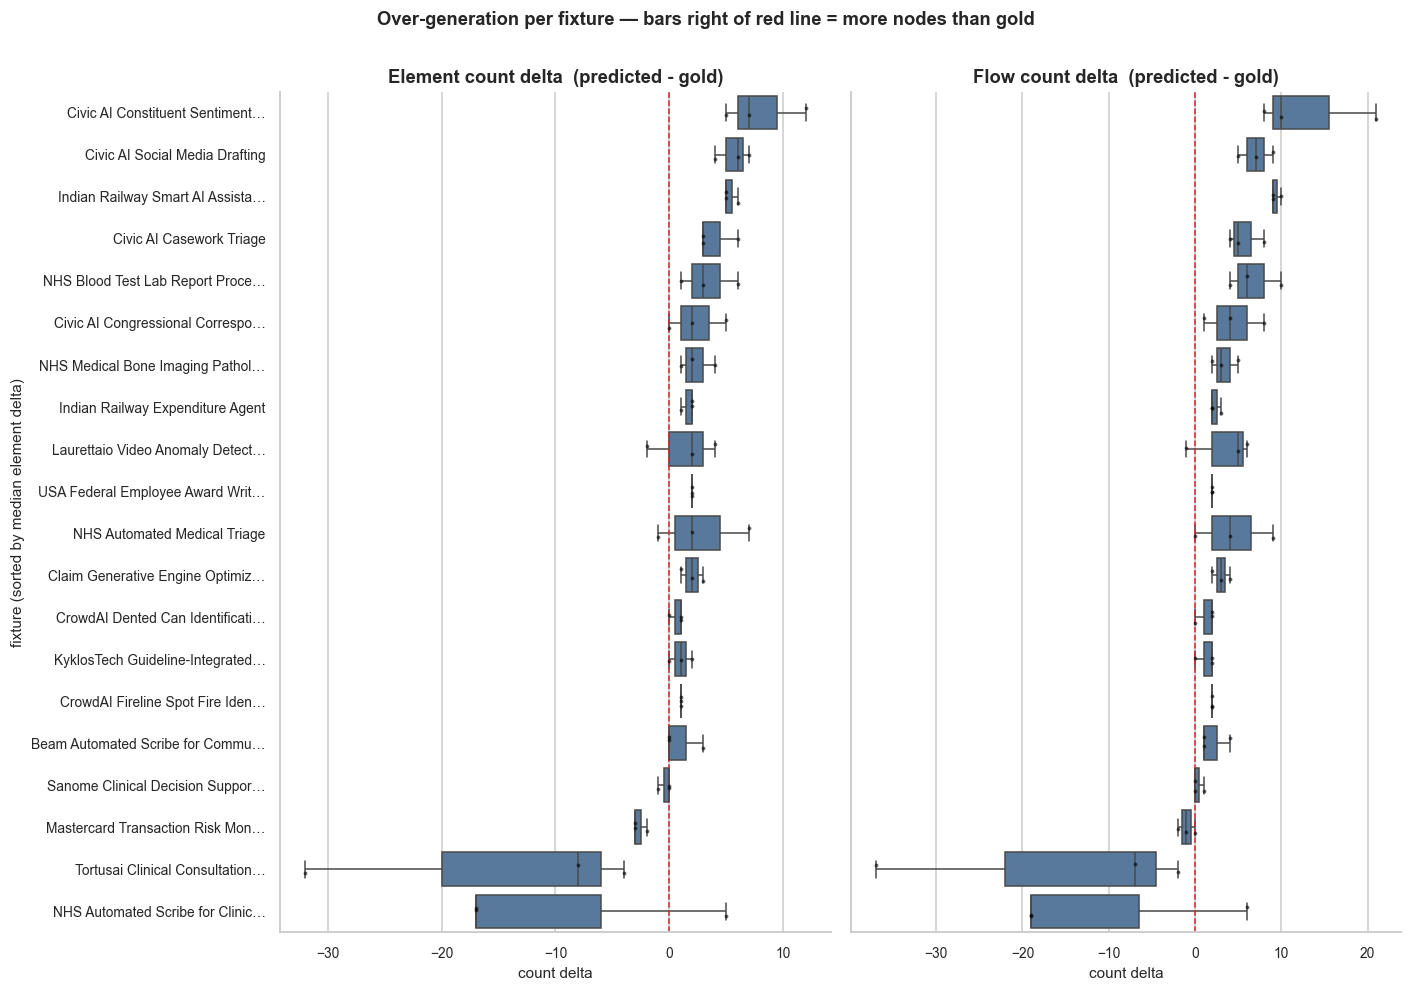

In [6]:
deltas = df.groupby("process_name")[["element_count_delta", "flow_count_delta", "gold_elements", "gold_flows"]].mean()
deltas["element_ratio"] = (deltas["gold_elements"] + deltas["element_count_delta"]) / deltas["gold_elements"]
display(deltas.round(2))

# One-sample t-test: is the mean element delta significantly different from 0?
t_el = stats.ttest_1samp(df["element_count_delta"], 0.0)
t_fl = stats.ttest_1samp(df["flow_count_delta"], 0.0)
print(f"\nElement delta: mean={df['element_count_delta'].mean():.2f}, t={t_el.statistic:.2f}, p={t_el.pvalue:.4f}")
print(f"Flow delta:    mean={df['flow_count_delta'].mean():.2f}, t={t_fl.statistic:.2f}, p={t_fl.pvalue:.4f}")

# Sort fixtures by median element delta so the eye reads top->bottom as "most over-generated".
order_pn = (df.groupby("process_name")["element_count_delta"].median()
              .sort_values(ascending=False).index.tolist())
order = [short_name(p) for p in order_pn]

fig, axes = plt.subplots(1, 2, figsize=(13, max(6, 0.35 * len(order_pn) + 2)), sharey=True)

for ax, col, title in [
    (axes[0], "element_count_delta", "Element count delta  (predicted - gold)"),
    (axes[1], "flow_count_delta",   "Flow count delta  (predicted - gold)"),
]:
    sns.boxplot(data=df, y="fixture", x=col, order=order, ax=ax,
                color="#4c78a8", fliersize=3, linewidth=1)
    sns.stripplot(data=df, y="fixture", x=col, order=order, ax=ax,
                  color="black", size=2.5, alpha=0.6, jitter=0.15)
    ax.axvline(0, color="#d62728", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("count delta")
    ax.set_ylabel("")

axes[0].set_ylabel("fixture (sorted by median element delta)")
fig.suptitle("Over-generation per fixture — bars right of red line = more nodes than gold", y=1.0, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## H3 - Complexity vs fidelity

**Claim:** As gold workflow size grows, type-distribution fidelity (`element_type_jaccard_multiset`) degrades.

**Why it matters:** Tells you whether the tool's failure profile is "small workflows over-elaborated" or "big workflows lose structure" - opposite UX implications.

Spearman gold_elements vs jaccard:        rho=-0.029  p=0.8275
Spearman gold_elements vs type_coverage:  rho=-0.348  p=0.0064


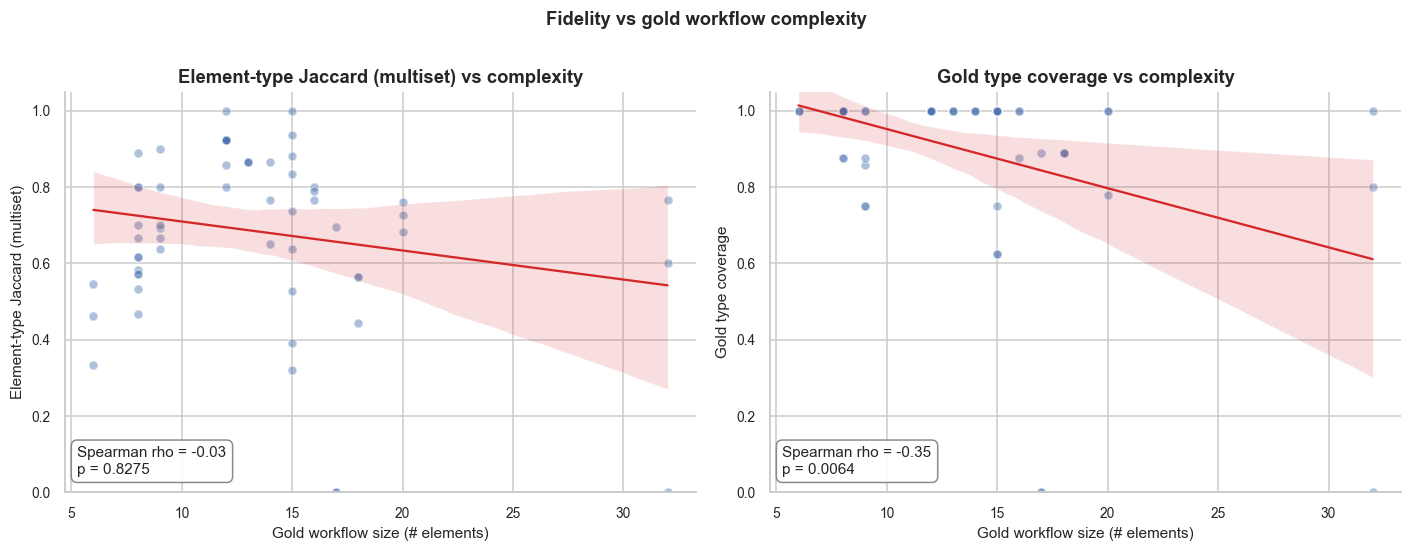

In [7]:
rho_j, p_j = stats.spearmanr(df["gold_elements"], df["element_type_jaccard_multiset"])
rho_c, p_c = stats.spearmanr(df["gold_elements"], df["gold_type_coverage"])
print(f"Spearman gold_elements vs jaccard:        rho={rho_j:.3f}  p={p_j:.4f}")
print(f"Spearman gold_elements vs type_coverage:  rho={rho_c:.3f}  p={p_c:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ycol, ylabel, rho, p in [
    (axes[0], "element_type_jaccard_multiset", "Element-type Jaccard (multiset)", rho_j, p_j),
    (axes[1], "gold_type_coverage",            "Gold type coverage",              rho_c, p_c),
]:
    sns.regplot(data=df, x="gold_elements", y=ycol, ax=ax,
                scatter_kws={"alpha": 0.45, "s": 35, "edgecolor": "white"},
                line_kws={"color": "#d62728", "linewidth": 1.5})
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Gold workflow size (# elements)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs complexity")
    ax.text(0.02, 0.04,
            f"Spearman rho = {rho:.2f}\np = {p:.4f}",
            transform=ax.transAxes,
            fontsize=10, va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.9))

fig.suptitle("Fidelity vs gold workflow complexity", fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## H4 - Lexical match (final outcomes) is weaker than structural match (types)

**Claim:** `final_outcome_recall` < `gold_type_coverage` on average, because matching the *names* of terminal nodes is harder than getting the *ontology* right.

**Why it matters:** Suggests the right deltaisn't ontology training - it's anchoring the LLM on user-supplied terminal phrases.

,gold_type_coverage,final_outcome_recall,element_type_jaccard_multiset
process_name,,,
Beam Automated Scribe for Community Care Worker,0.889,0.833,0.525
Civic AI Casework Triage,1.000,1.000,0.736
Civic AI Congressional Correspondence,1.000,0.000,0.760
Civic AI Constituent Sentiment Analysis,1.000,0.333,0.447
Civic AI Social Media Drafting,1.000,0.000,0.556
Claim Generative Engine Optimization for Webpages,1.000,0.333,0.860
CrowdAI Dented Can Identification,1.000,1.000,0.949
CrowdAI Fireline Spot Fire Identification,1.000,1.000,0.923
Indian Railway Expenditure Agent,1.000,1.000,0.830


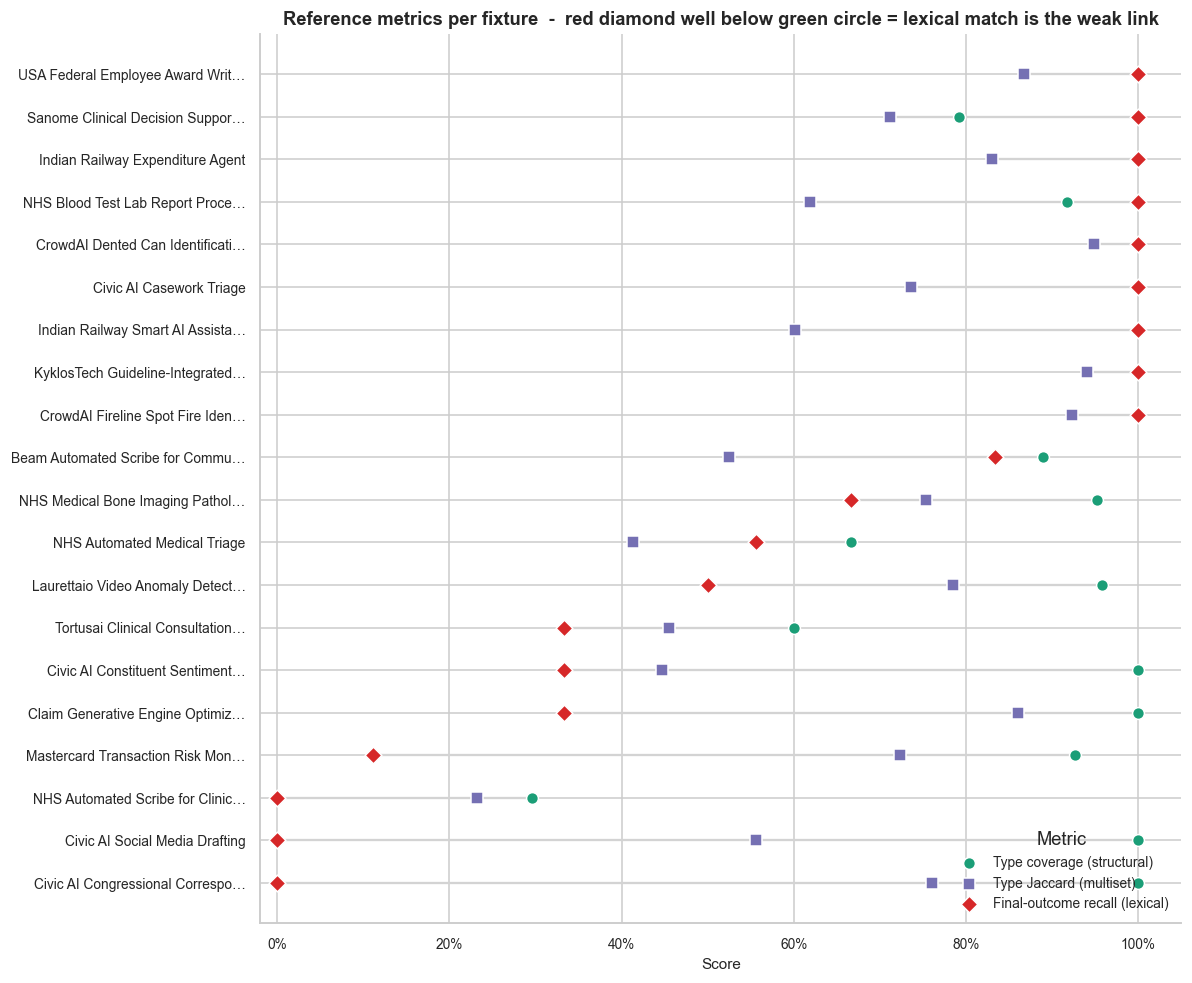


Paired t-test type_coverage vs final_outcome_recall: t=4.77, p=0.0000
  mean(type_coverage)        = 0.900
  mean(final_outcome_recall) = 0.633


In [8]:
ref = df.groupby("process_name")[["gold_type_coverage", "final_outcome_recall", "element_type_jaccard_multiset"]].mean()
display(ref.round(3))

# Cleveland-style dot plot: one row per fixture, three markers showing each metric.
# Sort by final_outcome_recall (the hypothesised weakest) so the gap to gold_type_coverage is visually obvious.
ref_sorted = ref.sort_values("final_outcome_recall")
ref_sorted.index = [short_name(p) for p in ref_sorted.index]

fig, ax = plt.subplots(figsize=(11, max(6, 0.38 * len(ref_sorted) + 1.5)))

palette = {
    "gold_type_coverage":             "#1b9e77",
    "element_type_jaccard_multiset":  "#7570b3",
    "final_outcome_recall":           "#d62728",
}
markers = {"gold_type_coverage": "o", "element_type_jaccard_multiset": "s", "final_outcome_recall": "D"}
labels = {
    "gold_type_coverage":             "Type coverage (structural)",
    "element_type_jaccard_multiset":  "Type Jaccard (multiset)",
    "final_outcome_recall":           "Final-outcome recall (lexical)",
}

y = np.arange(len(ref_sorted))

# Connecting line from min to max of the three metrics, per fixture.
mins = ref_sorted.min(axis=1).values
maxs = ref_sorted.max(axis=1).values
ax.hlines(y, mins, maxs, color="lightgrey", linewidth=1.5, zorder=1)

for metric in ["gold_type_coverage", "element_type_jaccard_multiset", "final_outcome_recall"]:
    ax.scatter(ref_sorted[metric].values, y,
               s=60, color=palette[metric], marker=markers[metric],
               label=labels[metric], edgecolor="white", zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(ref_sorted.index)
ax.set_xlim(-0.02, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Score")
ax.set_title("Reference metrics per fixture  -  red diamond well below green circle = lexical match is the weak link")
ax.legend(loc="lower right", title="Metric")
plt.tight_layout()
plt.show()

t = stats.ttest_rel(df["gold_type_coverage"], df["final_outcome_recall"])
print(f"\nPaired t-test type_coverage vs final_outcome_recall: t={t.statistic:.2f}, p={t.pvalue:.4f}")
print(f"  mean(type_coverage)        = {df['gold_type_coverage'].mean():.3f}")
print(f"  mean(final_outcome_recall) = {df['final_outcome_recall'].mean():.3f}")

## H5 - Is N=3 enough? (run-to-run variance)

**Claim:** Coefficient of variation (stdev / mean) is small enough on structural and reference metrics that N=3 gives a stable per-fixture estimate.

**Why it matters:** Methodological defense for the dissertation. If CV is high, you need bigger N on the full 20-system run.

,total_tokens,latency_ms,num_elements,num_flows,element_type_jaccard_multiset,gold_type_coverage,final_outcome_recall
NHS Automated Scribe for Clinic…,1.732,0.232,1.732,1.732,1.732,1.732,NaN
Tortusai Clinical Consultation…,0.866,0.525,0.874,0.874,0.885,0.882,0.866
Civic AI Constituent Sentiment…,0.046,0.039,0.258,0.389,0.239,0.000,1.732
Mastercard Transaction Risk Mon…,0.016,0.014,0.033,0.050,0.056,0.139,1.732
Claim Generative Engine Optimiz…,0.034,0.044,0.071,0.062,0.072,0.000,1.732
NHS Automated Medical Triage,0.063,0.388,0.229,0.222,0.252,0.108,0.693
Civic AI Casework Triage,0.061,1.410,0.091,0.096,0.134,0.000,0.000
Laurettaio Video Anomaly Detect…,0.073,0.097,0.176,0.196,0.023,0.075,1.000
NHS Blood Test Lab Report Proce…,0.054,0.617,0.222,0.208,0.115,0.079,0.000
NHS Medical Bone Imaging Pathol…,0.082,0.153,0.135,0.135,0.170,0.087,0.433


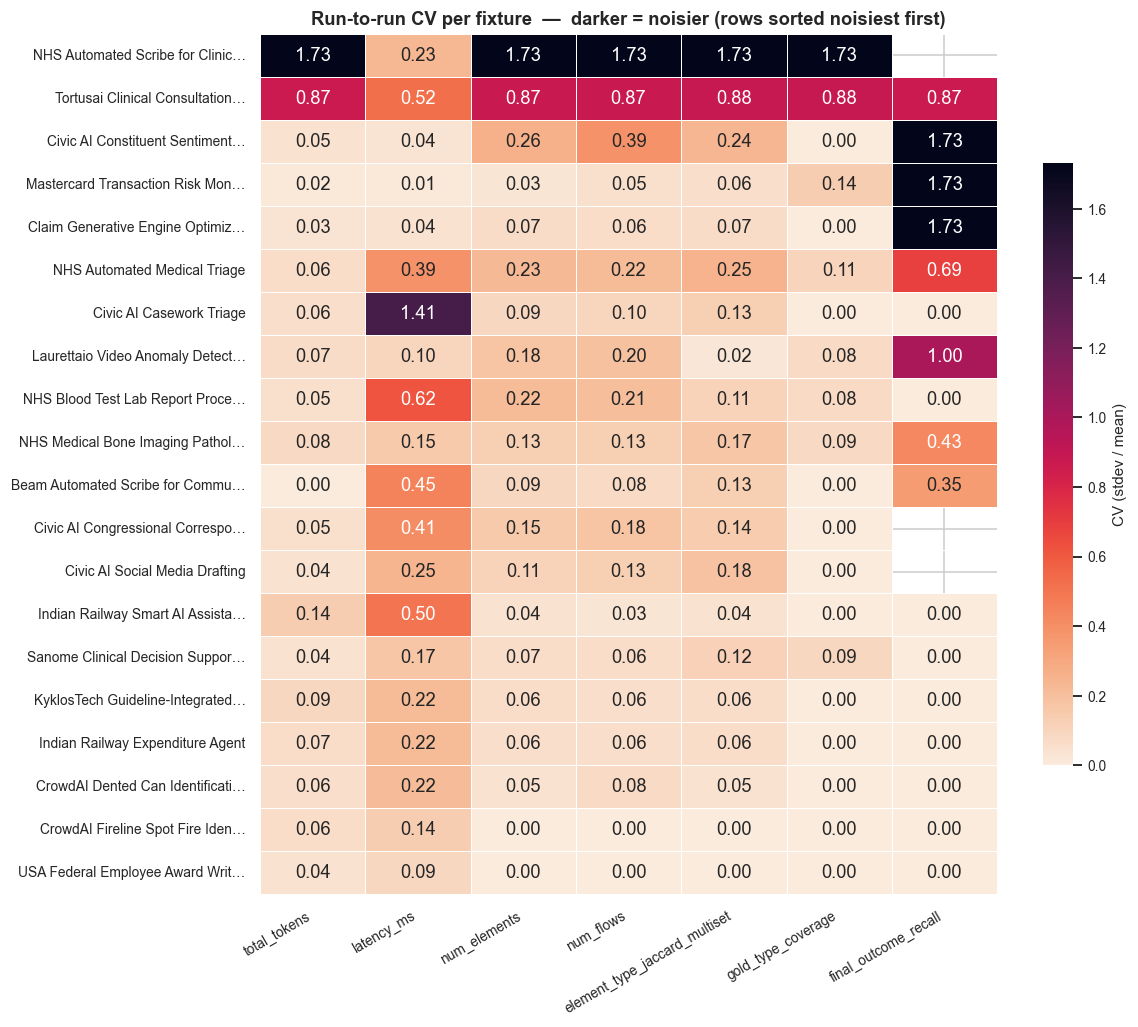

Rule of thumb: CV < 0.1 = very stable, 0.1–0.3 = acceptable, > 0.3 = noisy (need bigger N).


In [9]:
metrics = [
    "total_tokens", "latency_ms", "num_elements", "num_flows",
    "element_type_jaccard_multiset", "gold_type_coverage", "final_outcome_recall",
]
agg = df.groupby("process_name")[metrics].agg(["mean", "std"])
cv = pd.DataFrame({m: agg[(m, "std")] / agg[(m, "mean")].replace(0, np.nan) for m in metrics})

# Sort fixtures by mean CV (noisiest at top) so the eye lands on the rows that matter.
cv = cv.assign(_mean=cv.mean(axis=1)).sort_values("_mean", ascending=False).drop(columns="_mean")
cv.index = [short_name(p) for p in cv.index]
display(cv.round(3))

fig, ax = plt.subplots(figsize=(11, max(6, 0.4 * len(cv) + 1.5)))
sns.heatmap(
    cv, annot=True, fmt=".2f",
    cmap="rocket_r", vmin=0, vmax=max(0.5, float(np.nanmax(cv.values))),
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "CV (stdev / mean)", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Run-to-run CV per fixture  —  darker = noisier (rows sorted noisiest first)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Rule of thumb: CV < 0.1 = very stable, 0.1–0.3 = acceptable, > 0.3 = noisy (need bigger N).")

## H6 - Completion tokens scale ~linearly with output size

**Claim:** `completion_tokens ~ a + b * (num_elements + num_flows)`. Prompt tokens should be near-constant per fixture (system prompt + 3 few-shots + ~same user msg).

**Why it matters:** Lets you predict token spend on the full 20-system run, and exposes whether MAX_TRACE_TOKENS=16384 has enough headroom.

completion_tokens = -107.4 + 100.5 * (elements+flows)   r^2 = 0.740
prompt_tokens: mean=3603, stdev=833.9


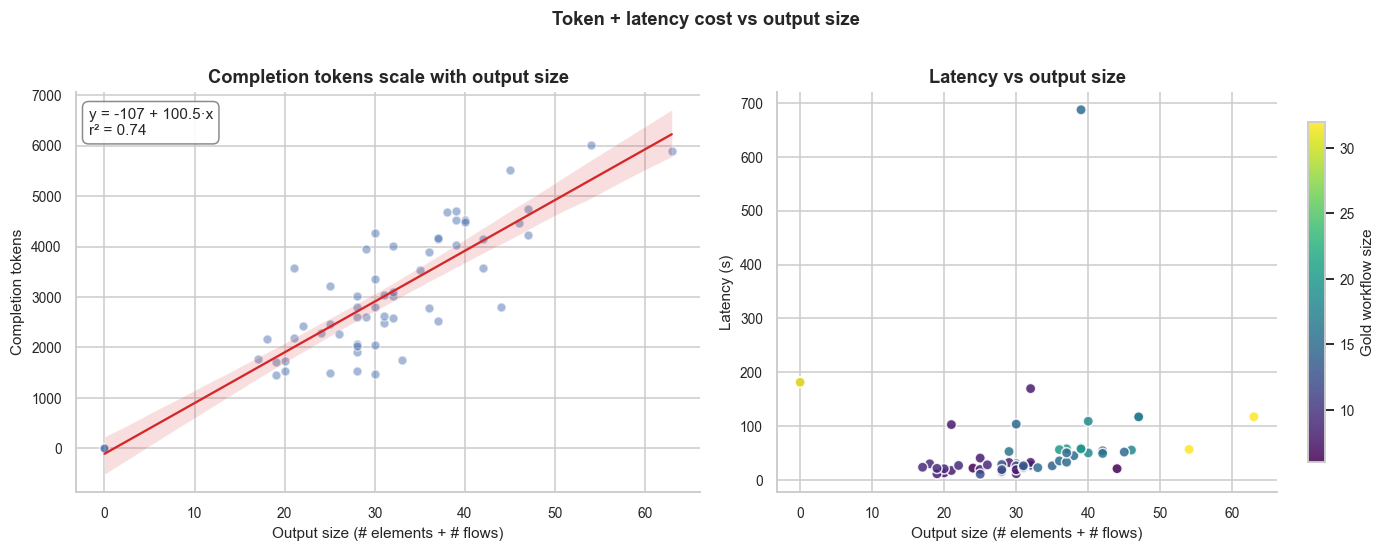

In [10]:
df["output_size"] = df["num_elements"] + df["num_flows"]
fit = stats.linregress(df["output_size"], df["completion_tokens"])
print(f"completion_tokens = {fit.intercept:.1f} + {fit.slope:.1f} * (elements+flows)   r^2 = {fit.rvalue**2:.3f}")
print(f"prompt_tokens: mean={df['prompt_tokens'].mean():.0f}, stdev={df['prompt_tokens'].std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: token scaling, with the fit equation in a corner annotation.
sns.regplot(
    data=df, x="output_size", y="completion_tokens", ax=axes[0],
    scatter_kws={"alpha": 0.5, "s": 35, "edgecolor": "white"},
    line_kws={"color": "#d62728", "linewidth": 1.5},
)
axes[0].set_xlabel("Output size (# elements + # flows)")
axes[0].set_ylabel("Completion tokens")
axes[0].set_title("Completion tokens scale with output size")
axes[0].text(0.02, 0.96,
             f"y = {fit.intercept:.0f} + {fit.slope:.1f}·x\nr² = {fit.rvalue**2:.2f}",
             transform=axes[0].transAxes, va="top", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.9))

# Right: latency vs output size, colored by gold_elements (a continuous proxy for fixture
# complexity) instead of by 20-category fixture name — the previous legend was unreadable.
sc = axes[1].scatter(
    df["output_size"], df["latency_ms"] / 1000,
    c=df["gold_elements"], cmap="viridis",
    s=45, alpha=0.85, edgecolor="white",
)
axes[1].set_xlabel("Output size (# elements + # flows)")
axes[1].set_ylabel("Latency (s)")
axes[1].set_title("Latency vs output size")
cbar = fig.colorbar(sc, ax=axes[1], shrink=0.85)
cbar.set_label("Gold workflow size")

fig.suptitle("Token + latency cost vs output size", fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

## Quick takeaways table

Per-fixture cheat sheet for the dissertation chapter. Mean values across N runs.

In [11]:
out = df.groupby("process_name").agg(
    n_runs=("run_idx", "count"),
    gold_elements=("gold_elements", "first"),
    pred_elements_mean=("num_elements", "mean"),
    element_delta_mean=("element_count_delta", "mean"),
    semantic_pass_rate=("semantic_pass", "mean"),
    jaccard_mean=("element_type_jaccard_multiset", "mean"),
    final_recall_mean=("final_outcome_recall", "mean"),
    total_tokens_mean=("total_tokens", "mean"),
    latency_s_mean=("latency_ms", lambda s: s.mean() / 1000),
).round(2)
out

,n_runs,gold_elements,pred_elements_mean,element_delta_mean,semantic_pass_rate,jaccard_mean,final_recall_mean,total_tokens_mean,latency_s_mean
process_name,,,,,,,,,
Beam Automated Scribe for Community Care Worker,3,18,19.00,1.00,1.00,0.52,0.83,8296.33,71.75
Civic AI Casework Triage,3,15,19.00,4.00,1.00,0.74,1.00,8730.67,261.60
Civic AI Congressional Correspondence,3,14,16.33,2.33,1.00,0.76,0.00,7792.33,37.04
Civic AI Constituent Sentiment Analysis,3,6,14.00,8.00,1.00,0.45,0.33,6413.67,22.08
Civic AI Social Media Drafting,3,8,13.67,5.67,1.00,0.56,0.00,6466.33,26.11
Claim Generative Engine Optimization for Webpages,3,12,14.00,2.00,1.00,0.86,0.33,6587.33,27.75
CrowdAI Dented Can Identification,3,12,12.67,0.67,1.00,0.95,1.00,5482.67,13.55
CrowdAI Fireline Spot Fire Identification,3,12,13.00,1.00,1.00,0.92,1.00,5973.33,16.81
Indian Railway Expenditure Agent,3,8,9.67,1.67,1.00,0.83,1.00,5551.00,14.26
